In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Na célula abaixo, foram definidas as funções Jacobi, Gauss Seidel e SOR, que serão amplamente utilizados nesta lista

In [ ]:
def Jacobi(A, x, b, tol):
    n = len(A)
    x_new = np.copy(x)
    erro = 2*tol
    it = 0
    while erro > tol:
        erro = 0.0
        for i in range(n):
            s = 0.0
            for j in range(n):
                s = s + A[i,j]*x[j]
            R = (1.0/A[i,i])*(b[i] - s)
            if (np.abs(R) > erro):
                erro = np.abs(R)
            x_new[i] = x[i] + R
        x = np.copy(x_new)
        it = it + 1
        #print(it, x)
    return x

def Gauss_Seidel(A, x, b, tol):
    n = len(A)
    x_new = np.copy(x)
    erro = 2*tol
    it = 0
    while erro > tol:
        erro = 0.0
        for i in range(n):
            s = 0.0
            for j in range(n):
                s = s + A[i,j]*x[j]
            R = (1.0/A[i,i])*(b[i] - s)
            if (np.abs(R) > erro):
                erro = np.abs(R)
            x[i] = x[i] + R
        it = it + 1
        #print(it, x)
    return x


def SOR(A, x, b, tol, omega):
    n = len(A)
    x_new = np.copy(x)
    erro = 2*tol
    it = 0
    while erro > tol:
        erro = 0.0
        for i in range(n):
            s = 0.0
            for j in range(n):
                s = s + A[i,j]*x[j]
            R = (1.0/A[i,i])*(b[i] - s)
            if (np.abs(R) > erro):
                erro = np.abs(R)
            x[i] = x[i] + omega*R
        it = it + 1
        #print(it, x)
    return x
def gradiente_conjugado(A, x, b, tol, omega):
  # Gradiente Conjugado
  r = b - np.dot(A, x)  # Residual inicial
  p = r.copy()   # Direção de busca inicial
  tol = 1e-5    # Tolerância para convergência
  max_iter = 1000
  it = 0
  for k in range(max_iter):
      Ap = np.dot(A, p)
      alpha = np.dot(r, r) / np.dot(p, Ap)
      x = x + alpha * p
      r_new = r - alpha * Ap

      if np.linalg.norm(r_new) < tol:
          break

      beta = np.dot(r_new, r_new) / np.dot(r, r)
      p = r_new + beta * p
      r = r_new
      it = it + 1
  return x

####################teste##################
'''
A = np.array([
    [4.0, 2.0, 1.0],
    [0.0, 3.0, 1.0],
    [2.0, 2.0, 5.0]
    ])
b = np.array(
    [7.0, 4.0, 9.0]
    )
x = np.array(
    [0.0, 0.0, 0.0]
    )
tol = 1e-5

print(Gauss_Seidel(A, x, b, tol))
'''

'''
print(' ')
print('Jacobi')
x = Jacobi(A, x, b, tol)

x = np.zeros(len(A))
print(' ')
print('Gauss Seidel')
x = Gauss_Seidel(A, x, b, tol)

x = np.zeros(len(A))
print(' ')
print('SOR')
x = SOR(A, x, b, tol, 1.1)
'''
'''
n = 20
A = np.zeros((n+1, n+1))
A[0,0] = 1.0
for i in range(1, n):
    A[i,i] = -2.0
    A[i, i+1] = 1.0
    A[i, i-1] = 1.0
A[n,n] = 1.0
b = np.zeros(n+1)
b[n] = 1.0
x = np.zeros(n+1)
print(Gauss_Seidel(A, x, b, tol))
'''

'\nn = 20\nA = np.zeros((n+1, n+1))\nA[0,0] = 1.0\nfor i in range(1, n):\n    A[i,i] = -2.0\n    A[i, i+1] = 1.0\n    A[i, i-1] = 1.0\nA[n,n] = 1.0\nb = np.zeros(n+1)\nb[n] = 1.0\nx = np.zeros(n+1)\nprint(Gauss_Seidel(A, x, b, tol))\n'

##**Exercício 1.**


In [ ]:
A = np.array([
    [12.0, -2.0, 3.0,1.0],
    [1.0, 6.0, 20.0, -4.0],
    [-2.0, 15.0, 6.0,-3.0],
    [0.0, -3.0, 2.0, 9.0]
    ])
b = np.array(
    [0.0,20.0,0.0,0.0]
    )
#chute inicial 0,0,0,0.
x = np.array(
    [0.0, 0.0, 0.0,0.0]
    )
tol = 1e-5

print(Gauss_Seidel(A, x, b, tol))

[nan nan nan nan]


<ipython-input-12-735e2958119b>:31: RuntimeWarning: overflow encountered in scalar multiply
  s = s + A[i,j]*x[j]
<ipython-input-12-735e2958119b>:31: RuntimeWarning: invalid value encountered in scalar add
  s = s + A[i,j]*x[j]


Aqui, podemos ver o resultado Nan, ou seja, o método não converge

##**Exercício 2**

In [ ]:
#Pela matriz da aula (eq 11)
A = np.array([
    [-2,1,0,0],
    [1,-2,1,0],
    [0,1,-2,1],
    [0,0,1,-2]
    ])
b = np.array(
    [0.0,0.0,0.0,-1.0]
    )
#chute inicial
x = np.array(
    [0.0, 0.0, 0.0,0.0]
    )

tol = 1e-7
#usnado as funcoes determinadas na celula de codigo numero 2, temos que:
print("Por Gauss_Seidel ", Gauss_Seidel(A, x.copy(), b, tol))
print("Por Jacobi ", Jacobi(A, x.copy(), b, tol))
print("Por SOR ", SOR(A, x.copy(), b, tol, 1.5))
print("Por gradiente conjugado ", gradiente_conjugado(A, x.copy(), b, tol))

Por Gauss_Seidel  (array([0.19999988, 0.39999985, 0.59999988, 0.79999994]), 37)
Por Jacobi  (array([0.19999988, 0.39999977, 0.59999981, 0.79999986]), 70)
Por SOR  (array([0.20000002, 0.39999997, 0.59999994, 0.8       ]), 24)
Por gradiente conjugado  (array([0.2, 0.4, 0.6, 0.8]), 3)


Podemos ver o numero de iteracoes:
Gauss Seidel-37
Jacobi-70
SOR-24
Gradiente Conjugado-3

Defina a dimensão máxima da matriz A: 10


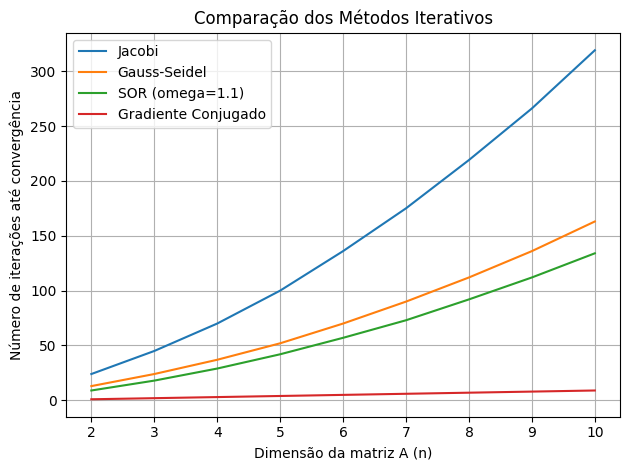

In [ ]:
#realizando a investigacao 1, o efeito do tamanho da matriz no numero de iteracoes
jacobi_its = []   #crio a lista para armazenar o numero de iteracoes
gs_its = []
sor_its = []
cg_its = []
dimensoes = []
n_max = int(input("Defina a dimensão máxima da matriz A: ")) # dimensao maxima para estudo, por favor, escolha um valor baixo, tipo 15 ou 20, pois sem o numba, demora demais
omega=1.1 #omega pode mudar, mas por simplicidade, vamos deixar 1.1
# loop sobre as dimensões
for n in range(2, n_max + 1): #crio a matriz A baseado no valor de n fornecido
    A = np.zeros((n, n))
    for i in range(n):
        A[i, i] = -2
        if i > 0:
            A[i, i - 1] = 1
        if i < n - 1:
            A[i, i + 1] = 1
    b = np.zeros(n) #matriz b
    b[-1] = -1.0
    x0 = np.zeros(n) # chute inicial
    # chamo os metodos
    _, j_it = Jacobi(A, x0.copy(), b, tol)
    _, gs_it = Gauss_Seidel(A, x0.copy(), b, tol)
    _, sor_it = SOR(A, x0.copy(), b, tol, omega)
    _, cg_it = gradiente_conjugado(A, x0.copy(), b, tol)
    #armazeno os resultados
    jacobi_its.append(j_it)
    gs_its.append(gs_it)
    sor_its.append(sor_it)
    cg_its.append(cg_it)
    dimensoes.append(n)
#ploto os graficos
plt.plot(dimensoes, jacobi_its, label='Jacobi')
plt.plot(dimensoes, gs_its, label='Gauss-Seidel')
plt.plot(dimensoes, sor_its, label='SOR (omega=1.1)')
plt.plot(dimensoes, cg_its, label='Gradiente Conjugado')
plt.xlabel("Dimensão da matriz A (n)")
plt.ylabel("Número de iterações até convergência")
plt.title("Comparação dos Métodos Iterativos")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Podemos perceber aqui que o metodo mais potente e o Gradiente conjugado, dado que ele converge com pouquissimas iteracoes quando comparado com outros metodos e e o menos afetado pelo tamanho da matriz

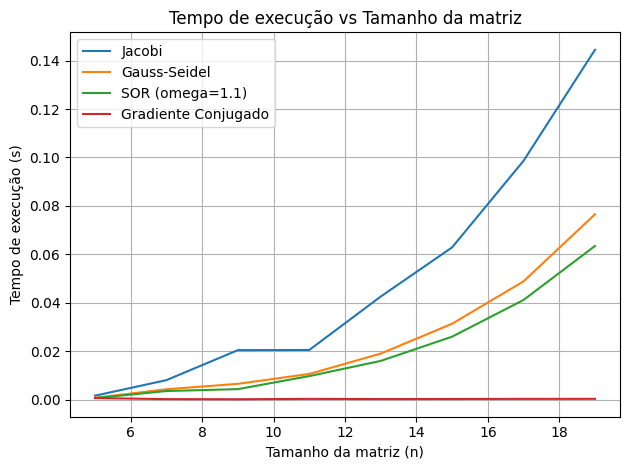

In [ ]:
#investigacao II
import time
#parametros
tol=1e-7
omega=1.1
n_vals = range(5,20,2)  #de 5 até 15, de 2 em 2

#armazeno os tempos
tempos_jacobi = []
tempos_gs = []
tempos_sor = []
tempos_cg = []

for n in n_vals:
#faco a matriz tridiagonal
    A = np.diag([-2.0]*n) + np.diag([1.0]*(n-1), k=1) + np.diag([1.0]*(n-1), k=-1)
    b = np.zeros(n)
    b[-1] = -1.0
    x0 = np.zeros(n)
#jacobi
    t0 = time.time()
    _, _ = Jacobi(A, x0.copy(), b, tol)
    t1 = time.time()
    tempos_jacobi.append(t1 - t0)
#GAUSS
    t0 = time.time()
    _, _ = Gauss_Seidel(A, x0.copy(), b, tol)
    t1 = time.time()
    tempos_gs.append(t1 - t0)

#SOR
    t0 = time.time()
    _, _ = SOR(A, x0.copy(), b, tol, omega)
    t1 = time.time()
    tempos_sor.append(t1 - t0)
#Gradiente conjugado
    t0 = time.time()
    _, _ = gradiente_conjugado(A, x0.copy(), b, tol)
    t1 = time.time()
    tempos_cg.append(t1 - t0)

#ploto
plt.plot(n_vals, tempos_jacobi, label='Jacobi')
plt.plot(n_vals, tempos_gs, label='Gauss-Seidel')
plt.plot(n_vals, tempos_sor, label='SOR (omega=1.1)')
plt.plot(n_vals, tempos_cg, label='Gradiente Conjugado')
plt.xlabel('Tamanho da matriz (n)')
plt.ylabel('Tempo de execução (s)')
plt.title('Tempo de execução vs Tamanho da matriz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Podemos ver novamente que o Gradiente Conjugado e o metodo que converge mais rapidamente, sendo, mais uma vez, o metodo que e menos afetado pelo tamanho da matriz (valor de n).

##**Exercício 3.**

Resultado após 71 iterações:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.01106261 0.02097131 0.0287464  0.03368408 0.03537543
  0.03368777 0.0287527  0.0209782  0.01106746 0.        ]
 [0.         0.0232844  0.0440842  0.06033979 0.07062457 0.07413945
  0.07063117 0.06035105 0.04409651 0.02329306 0.        ]
 [0.         0.03799873 0.07175292 0.09791778 0.1143493  0.11994009
  0.11435784 0.09793234 0.07176884 0.03800994 0.        ]
 [0.         0.05696719 0.10702475 0.14524526 0.16893148 0.17692941
  0.16894092 0.14526135 0.10704234 0.05697957 0.        ]
 [0.         0.08285536 0.15414798 0.20712377 0.2392192  0.24992115
  0.23922853 0.20713966 0.15416536 0.0828676  0.        ]
 [0.         0.12031587 0.2196015  0.28989825 0.33091644 0.34432233
  0.33092478 0.28991246 0.21961703 0.12032681 0.        ]
 [0.         0.17881483 0.31405532 0.40196445 0.45023943 0.46553936
  0.45024609 0.40197581 0.314

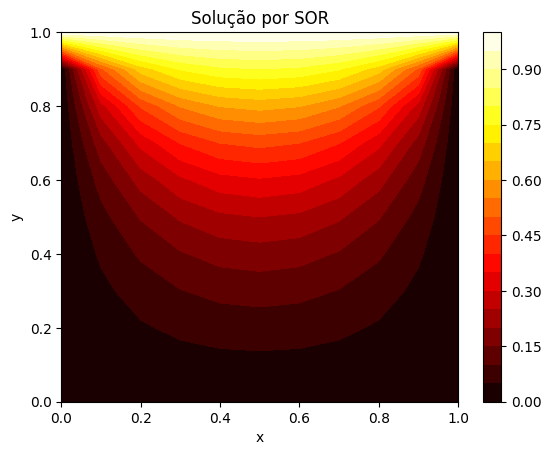

Resultado após 3171 iterações:
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 9.99678605e-05 1.99843501e-04 ... 2.00895409e-04
  1.00505077e-04 0.00000000e+00]
 [0.00000000e+00 2.00069085e-04 3.99953530e-04 ... 4.02055117e-04
  2.01142380e-04 0.00000000e+00]
 ...
 [0.00000000e+00 3.02110418e-01 4.99526193e-01 ... 4.99528231e-01
  3.02111459e-01 0.00000000e+00]
 [0.00000000e+00 4.99881539e-01 6.97415757e-01 ... 6.97416776e-01
  4.99882060e-01 0.00000000e+00]
 [1.00000000e+00 1.00000000e+00 1.00000000e+00 ... 1.00000000e+00
  1.00000000e+00 1.00000000e+00]]


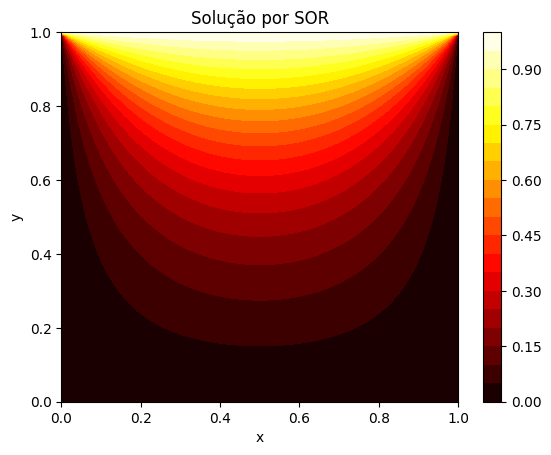

In [ ]:
def solve_SOR(N, tol, omega):
    T = np.zeros((N+1, N+1), dtype=float)
    R = np.zeros((N+1, N+1), dtype=float)

    # Condições de contorno
    T[:,0] = 0
    T[:,N] = 0
    T[0,:] = 0
    T[N,:] = 1

    iter_count = 0

    while True:
        for i in range(1, N):
            for j in range(1, N):
                # Calcula o resíduo local
                R[i, j] = 0.25 * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1] - 4 * T[i, j])
                # Atualiza T
                T[i, j] = T[i, j] + omega * R[i, j]

        iter_count += 1

        # Critério de parada
        if np.max(np.abs(R)) < tol:
            break
    return T, iter_count
# Agora funciona corretamente
x = np.linspace(0, 1, 11)
y = np.linspace(0, 1, 11)
X, Y = np.meshgrid(x, y)
result, iterations = solve_SOR(10, 1e-5, 1.1)
print("Resultado após", iterations, "iterações:")
print(result)
cp = plt.contourf(X, Y, result, 20, cmap='hot')
plt.colorbar(cp)
plt.title("Solução por SOR")
plt.xlabel('x')
plt.ylabel('y')
plt.show()
#agora, com 100 pontos
x = np.linspace(0, 1, 101)
y = np.linspace(0, 1, 101)
X, Y = np.meshgrid(x, y)
result, iterations = solve_SOR(100, 1e-5, 1.1)
print("Resultado após", iterations, "iterações:")
print(result)
cp = plt.contourf(X, Y, result, 20, cmap='hot')
plt.colorbar(cp)
plt.title("Solução por SOR")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

O computador levou certa de 90 segundos para terminar de resolver o problema.

O valor otimo de omega depende da malha, um omega muito pequeno torna a solucao mais estavel, mas converge mais lentamente enquanto que um omega maior converge mais rapidamente mas a solucao pode ser mais instavel. Para a malha usada, um omega de 1.5 seria o ideal

##**Exercício 4.**

Número de pontos do espaço: 10
SOR
Solução encontrada após 77 iterações.
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.09626915 0.18311614 0.25203947 0.29629207 0.3115418
  0.29629554 0.25204539 0.18312261 0.09627371 0.        ]
 [0.         0.18311614 0.34830998 0.47941064 0.56358441 0.59259108
  0.56359062 0.47942122 0.34832154 0.18312428 0.        ]
 [0.         0.25203947 0.47941064 0.65985613 0.7757118  0.81563601
  0.77571983 0.6598698  0.4794256  0.25205    0.        ]
 [0.         0.29629207 0.56358441 0.7757118  0.91190878 0.95884244
  0.91191764 0.77572691 0.56360094 0.29630371 0.        ]
 [0.         0.3115418  0.59259108 0.81563601 0.95884244 1.00819135
  0.9588512  0.81565094 0.59260741 0.3115533  0.        ]
 [0.         0.29629554 0.56359062 0.77571983 0.91191764 0.9588512
  0.91192547 0.77573317 0.56360521 0.29630582 0.        ]
 [0.         0.25204539 0.47942122 0.6598698  0.7757269

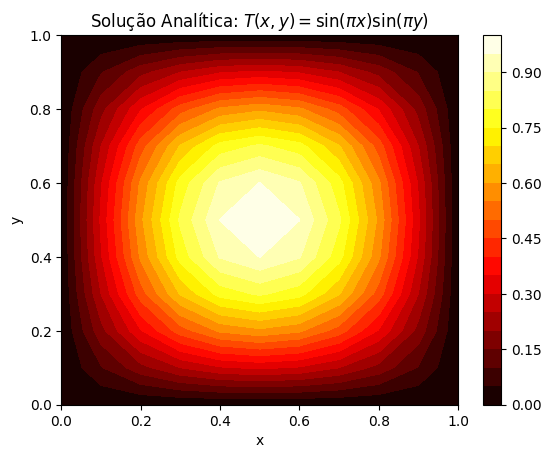

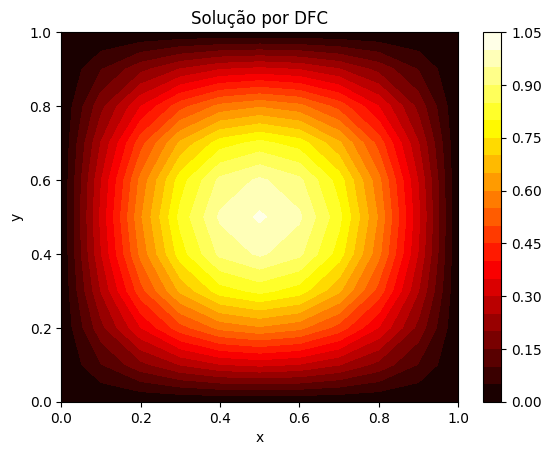

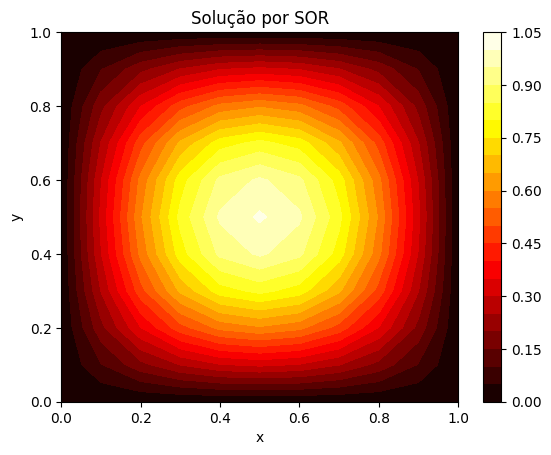

In [ ]:
def solve_SOR(N, tol, omega):
    dx = 1.0 / N
    T = np.zeros((N+1, N+1), dtype=float) #discretizacao
    R = np.zeros((N+1, N+1), dtype=float)
    x = np.linspace(0, 1, N+1)
    y = np.linspace(0, 1, N+1)
#condicoes de contorno
    T[:,0] = 0
    T[:,N] = 0
    T[0,:] = 0
    T[N,:] = 0
    it = 0
    while True:
        for i in range(1, N):
            for j in range(1, N):
                #funcao fonte
                f = -2 * np.pi**2 * np.sin(np.pi * x[i]) * np.sin(np.pi * y[j])
                #calc do residuo
                R[i, j] = 0.25 * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1] - dx**2 * f) - T[i, j]
                #atualizo T
                T[i, j] = T[i, j] + omega * R[i, j]
        it += 1
        #criterio de parada, para me protejer
        if np.max(np.abs(R)) < tol:
            break
    return T, it
N = int(input('Número de pontos do espaço: '))
T_resultado, iteracoes = solve_SOR(N, 1e-5, 1.1)
def solve_DFC(N, tol):
    dx = 1.0 / N
    T = np.zeros((N+1, N+1), dtype=float)
    R = np.zeros((N+1, N+1), dtype=float)
    x = np.linspace(0, 1, N+1)
    y = np.linspace(0, 1, N+1)

    #cond de contorno
    T[:, 0] = 0
    T[:, N] = 0
    T[0, :] = 0
    T[N, :] = 0
    it = 0
    while True:
        for i in range(1, N):
            for j in range(1, N):
                f = -2 * np.pi**2 * np.sin(np.pi * x[i]) * np.sin(np.pi * y[j])
                R[i, j] = 0.25 * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1] - dx**2 * f) - T[i, j]
                T[i, j] = T[i, j] + R[i, j]  # omega = 1
        it += 1
        if np.max(np.abs(R)) < tol:
            break

    return T, it

T_resultado1, iteracoes1 = solve_DFC(N, 1e-5)
print("SOR")
print("Solução encontrada após", iteracoes, "iterações.")
print(T_resultado)

print("DFC")
print("Solução encontrada após", iteracoes1, "iterações.")
print(T_resultado1)

def analytical_solution(x, y):
    return np.sin(np.pi * x) * np.sin(np.pi * y)
x = np.linspace(0, 1, N+1)
y = np.linspace(0, 1, N+1)
X, Y = np.meshgrid(x, y)
T_analytical = analytical_solution(X, Y)
cp = plt.contourf(X, Y, T_analytical, 20, cmap='hot')
plt.colorbar(cp)
plt.title('Solução Analítica: $T(x,y) = \sin(\pi x) \sin(\pi y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

cp = plt.contourf(X, Y, T_resultado1, 20, cmap='hot')
plt.colorbar(cp)
plt.title("Solução por DFC")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

cp = plt.contourf(X, Y, T_resultado, 20, cmap='hot')
plt.colorbar(cp)
plt.title("Solução por SOR")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Podemos ver que ambas as solucoes sao similares a solucao analitica, que era o esperado.

##**Exercício 5.**

Temperatura final: [0.         0.03005493 0.06519559 0.11057717 0.17135229 0.25230945
 0.35716531 0.48757931 0.64214433 0.81578194 1.        ]
Iterações totais: 118
Tempo final simulado: 0.10000000000000003


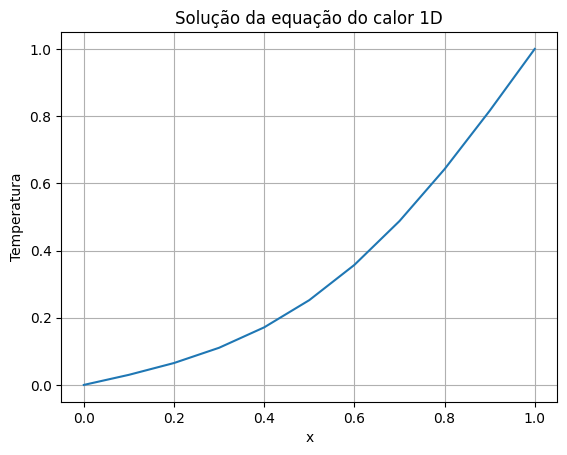

Temperatura final: [0.         0.03097915 0.06790561 0.11645121 0.1816485  0.26740163
 0.37591664 0.50717687 0.65863126 0.82524729 1.        ]


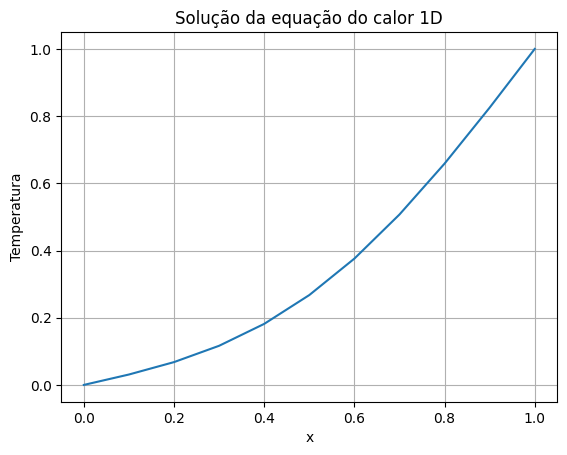

In [ ]:
#pelo metodo BTCS
def btcs(N, tol=1e-5, tfinal=0.1, omega=1.0):
    dx = 1.0 / N
    dt = dx**2
    r = dt / dx**2  # normalmente r=1 aqui

    T = np.zeros(N+1, dtype=float)
    T[0] = 0.0
    T[N] = 1.0

    Tnovo = T.copy()
    t = 0.0
    iter_total = 0

    while t < tfinal:
        iter_count = 0

        while True:
            iter_count += 1
            T_old = Tnovo.copy()

            for i in range(1, N):
                # Método Gauss-Seidel (pode usar omega para SOR)
                Tnovo[i] = (1 - omega)*Tnovo[i] + (omega / (1 + 2*r)) * (T[i] + r*(Tnovo[i-1] + Tnovo[i+1]))

            # Critério de convergência
            if np.max(np.abs(Tnovo - T_old)) < tol:
                break

        T = Tnovo.copy()
        iter_total += iter_count
        t += dt

    return T, iter_total, t

# Teste
N = 10
T_final, total_iters, final_time = btcs(N)
print(f"Temperatura final: {T_final}")
print(f"Iterações totais: {total_iters}")
print(f"Tempo final simulado: {final_time}")
x = np.linspace(0,1,N+1)
plt.plot(x, T_final)
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.title("Solução da equação do calor 1D BTCS")
plt.grid()
plt.show()

#Pelo metodo crank nickelson

def crank(N, tfinal, dt):
    dx = 1.0 / N
    alpha = dt / dx**2
    if alpha > 0.5:
        print("Aviso: esquema explícito pode ser instável com alpha =", alpha)

    T = np.zeros(N+1)
    T[0] = 0.0
    T[N] = 1.0

    t = 0.0
    while t < tfinal:
        T_new = T.copy()
        for i in range(1, N):
            T_new[i] = T[i] + alpha * (T[i+1] - 2*T[i] + T[i-1])
        T = T_new
        t += dt

    return T

#parametros
N = 10
tfinal = 0.1
dx = 1.0 / N
dt = 0.4 * dx**2

T_final =crank(N, tfinal, dt)
print("Temperatura final:", T_final)
#plot
x = np.linspace(0,1,N+1)
plt.plot(x, T_final)
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.title("Solução da equação do calor 1D Crank Nickelson")
plt.grid()
plt.show()

Aqui, podemos perceber a similaridade de ambos os metodos, demonstrando um alto grau de precisao numerica.

##**Exercício 6.**

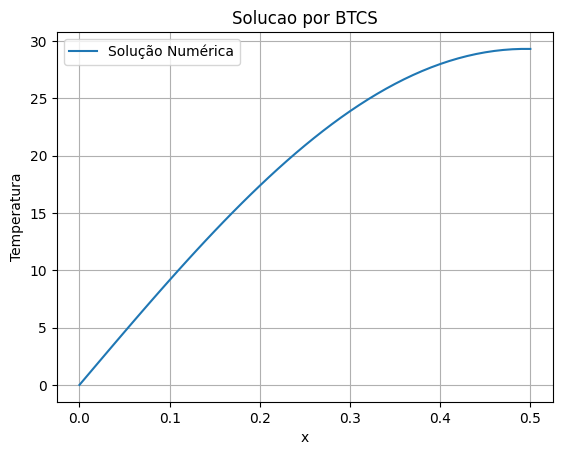

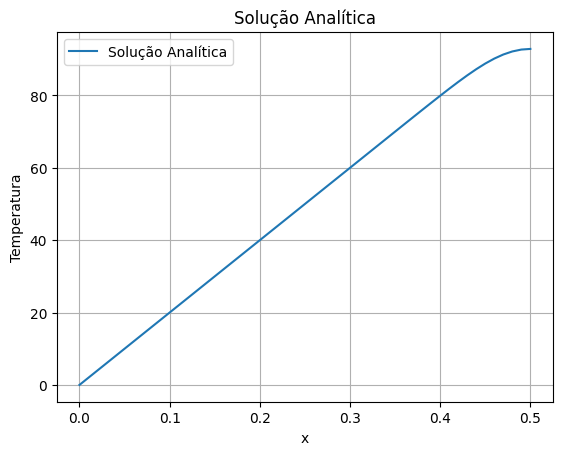

In [ ]:
#com cond de Neumann agr

def btcs(N, tfinal, dt):
    L = 0.5  # comprimento do domínio
    dx = L / N
    alpha = dt / dx**2
    if alpha > 0.5:
        print("Aviso: esquema explícito pode ser instável com alpha =", alpha)

    x = np.linspace(0, L, N+1)
    T = 200 * x  # condição inicial T(x,0) = 200x
    T[0] = 0
#cond de neumann entra no loop
    t = 0.0
    while t < tfinal:
        T_new = T.copy()
        for i in range(1, N):
            T_new[i] = T[i] + alpha * (T[i+1] - 2*T[i] + T[i-1])
        T_new[N] = T_new[N-1] #neumann
        T = T_new
        t += dt

    return T, x

#parametros
N = 50
tfinal = 0.1
dx = 0.5 / N
dt = 0.4 * dx**2

T_final, x = btcs(N, tfinal, dt)



#sol anal
termo=0
n=0
sol_analitica=np.zeros_like(x)  #inicializa como vetor
n_termos=10 #numero de termos para a soma da serie
Temperatura_nova=np.copy(T)  #copiando um vetor de temperatura novo para garantir que os valores novos nao sejam calculados a partir dos antigos
for m in range(n_termos):
    n=2*m + 1
    A=800*(-1)**m/(n**2 * np.pi**2)
    termo=A*np.sin(n * np.pi * x) * np.exp(-n**2 * np.pi**2 * 0.01 * t)
    sol_analitica += termo
#plot
plt.plot(x, T_final, label="Solução Numérica")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.title("Solucao por BTCS")
plt.grid(True)
plt.legend()
plt.show()

plt.plot(x, sol_analitica, label="Solução Analítica")
plt.xlabel("x")
plt.ylabel("Temperatura")
plt.title("Solução Analítica")
plt.grid(True)
plt.legend()
plt.show()


Aqui, podemos ver que a solucao analitica se aproxima mais de uma reta do tipo y=ax, isso se deve ao fato de que, provavelmente, o tempo simulado pelo metodo numerico nao foi suficiente para chegar em regime permanente.

comentario

##**Exercício 7.**

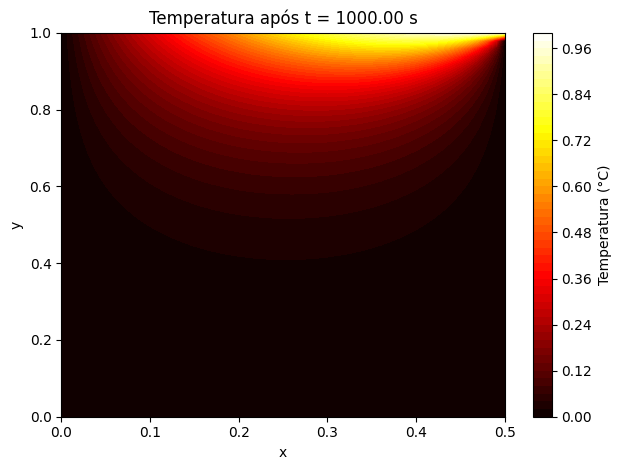

In [ ]:
N = 50
Lx = 0.5
Ly = 1.0
dx = Lx / N
dy = Ly / N
alpha = 1.0e-4
dt = 0.25 * min(dx, dy)**2 / alpha
t_final = 1000
n_steps = int(np.ceil(t_final / dt))

T = np.zeros((N+1, N+1), dtype=float)
T_new = np.zeros_like(T)

# Coordenadas da malha
x = np.linspace(0, Lx, N+1)
y = np.linspace(0, Ly, N+1)

# Loop de tempo
for step in range(n_steps):
    # Condições de contorno a cada passo de tempo:
    T[0, :] = 0.0                 # T(x=0, y, t) = 0
    T[N, :] = 0.0                 # T(x=0.5, y, t) = 0  (antes era Neumann, agora Dirichlet)
    T[:, 0] = 0.0                 # T(x, y=0, t) = 0
    T[:, N] = np.sin(np.pi * x)   # T(x, y=1, t) = sin(pi*x)

    for i in range(1, N):
        for j in range(1, N):
            tx = (T[i+1, j] - 2*T[i, j] + T[i-1, j]) / dx**2
            ty = (T[i, j+1] - 2*T[i, j] + T[i, j-1]) / dy**2
            T_new[i, j] = T[i, j] + alpha * dt * (tx + ty)

    T[1:N, 1:N] = T_new[1:N, 1:N]

# Malha para plot
X, Y = np.meshgrid(x, y)

# Plot
contour = plt.contourf(X, Y, T.T, cmap="hot", levels=50)
plt.colorbar(contour, label="Temperatura (°C)")
plt.title(f"Temperatura após t = {t_final:.2f} s")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


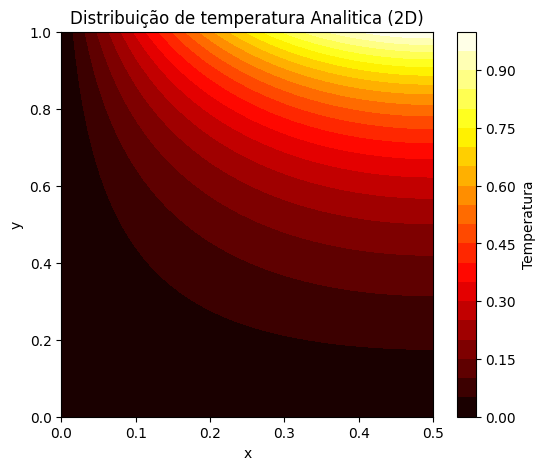

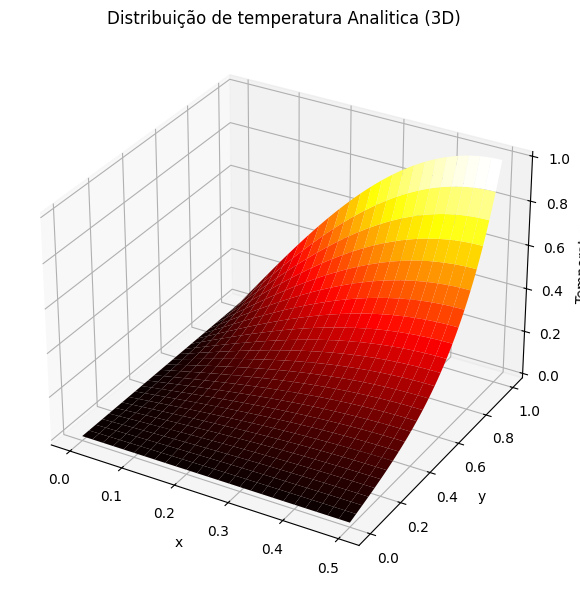

In [ ]:
#plot da sol. analitica (a mesma da lista 2)

T = (np.sinh(np.pi * Y) * np.sin(np.pi * X)) / np.sinh(np.pi)
#plot 2d sol anal
plt.figure(figsize=(6,5))
contour = plt.contourf(X, Y, T, 20, cmap='hot')
plt.colorbar(contour, label='Temperatura')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Distribuição de temperatura Analitica (2D)')
plt.show()

#plot 3d sol anal
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, T, cmap='hot')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Temperatura')
ax.set_title('Distribuição de temperatura Analitica (3D)')
plt.tight_layout()
plt.show()

Neste problema, coloquei um t muito grande, pois, para valores de t menores, o grafico ficava predominantemente preto, ou seja, a temperatura nao se espalhava ao longo do dominio, fazendo com que apenas a parte superior do grafico ficasse com uma temperatura diferente de zero. Mesmo assim, a convergencia nao foi satisfatoria. Um detalhe interessante e que as solucoes analiticas para as questoes 7 e 8 sao as mesmas, embora a questao 8 apresente a condicao de Neumann.

##**Exercício 8.**

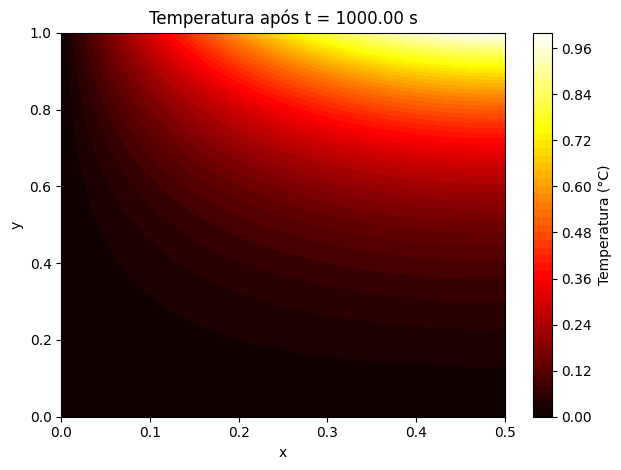

In [ ]:
N = 50
Lx = 0.5
Ly = 1.0
dx = Lx / N
dy = Ly / N
alpha = 1.0e-4
dt = 0.25 * min(dx, dy)**2 / alpha
t_final = 1000
n_steps = int(np.ceil(t_final / dt))

T = np.zeros((N+1, N+1), dtype=float)
T_new = np.zeros_like(T)

# Coordenadas da malha
x = np.linspace(0, Lx, N+1)
y = np.linspace(0, Ly, N+1)

# Loop de tempo
for step in range(n_steps):
    # Aplicar condições de contorno a cada passo de tempo:
    T[0, :] = 0.0  # T(x=0, y, t) = 0
    T[N, :] = T[N-1, :]  # ∂T/∂x = 0 em x=0.5
    T[:, 0] = 0.0  # T(x, y=0, t) = 0
    T[:, N] = np.sin(np.pi * x)  # T(x, y=1, t) = sin(pi*x)

    for i in range(1, N):
        for j in range(1, N):
            tx = (T[i+1, j] - 2*T[i, j] + T[i-1, j]) / dx**2
            ty = (T[i, j+1] - 2*T[i, j] + T[i, j-1]) / dy**2
            T_new[i, j] = T[i, j] + alpha * dt * (tx + ty)

    T[1:N, 1:N] = T_new[1:N, 1:N]
#malhap p/ plot
X, Y = np.meshgrid(x, y)

#plot
contour = plt.contourf(X, Y, T.T, cmap="hot", levels=50)
plt.colorbar(contour, label="Temperatura (°C)")
plt.title(f"Temperatura após t = {t_final:.2f} s")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


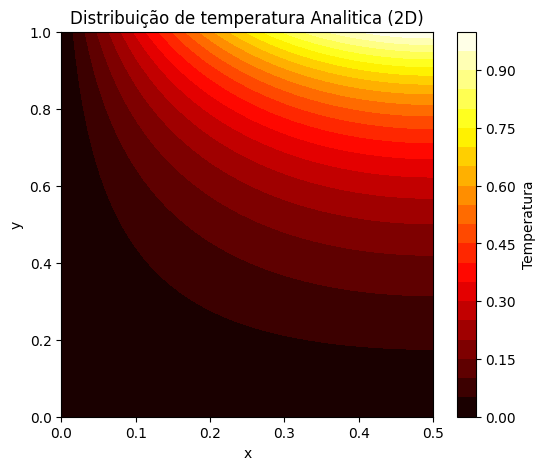

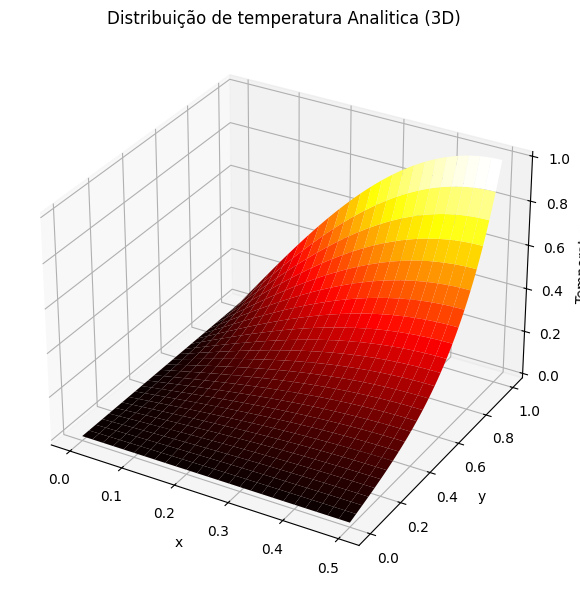

In [ ]:
#plot da sol. analitica (a mesma da lista 2)

T = (np.sinh(np.pi * Y) * np.sin(np.pi * X)) / np.sinh(np.pi)
#plot 2d sol anal
plt.figure(figsize=(6,5))
contour = plt.contourf(X, Y, T, 20, cmap='hot')
plt.colorbar(contour, label='Temperatura')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Distribuição de temperatura Analitica (2D)')
plt.show()

#plot 3d sol anal
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, T, cmap='hot')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('Temperatura')
ax.set_title('Distribuição de temperatura Analitica (3D)')
plt.tight_layout()
plt.show()

Para este caso, o grafico esta muito mais parecido com a solucao analitica. Para valotes de "t" intermediarios, ele demonstra tambem, uma convergencia melhor